# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**


In [1]:
!pip install rdkit

## **Install conda and rdkit**

## **Load bioactivity data**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('bioactivity_preprocessed_data.csv')

## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [4]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [5]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [7]:
df_cleaned = df.dropna(subset=['canonical_smiles'])
df_lipinski = lipinski(df_cleaned.canonical_smiles)

### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [8]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,383.814,4.45034,3.0,4.0
1,383.814,4.45034,3.0,4.0
2,383.814,4.45034,3.0,4.0
3,482.903,3.61432,3.0,6.0
4,482.903,3.61432,3.0,6.0
...,...,...,...,...
25175,444.875,3.85250,3.0,8.0
25176,458.902,4.24260,3.0,8.0
25177,458.902,4.24260,3.0,8.0
25178,446.910,4.27560,1.0,7.0


In [9]:
df

,molecule_chembl_id,canonical_smiles,standard_value
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.000
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.000
2,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7820.000
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.000
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.000
...,...,...,...
25194,CHEMBL6191667,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,9.800
25195,CHEMBL6192203,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,130.100
25196,CHEMBL6191199,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,4.810
25197,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,13.080


Now, let's combine the 2 DataFrame

In [10]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [11]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.000,383.814,4.45034,3.0,4.0
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.000,383.814,4.45034,3.0,4.0
2,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7820.000,383.814,4.45034,3.0,4.0
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.000,482.903,3.61432,3.0,6.0
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.000,482.903,3.61432,3.0,6.0
...,...,...,...,...,...,...,...
25194,CHEMBL6191667,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,9.800,NaN,NaN,NaN,NaN
25195,CHEMBL6192203,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,130.100,NaN,NaN,NaN,NaN
25196,CHEMBL6191199,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,4.810,NaN,NaN,NaN,NaN
25197,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,13.080,NaN,NaN,NaN,NaN


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [12]:


import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [13]:
df_combined.standard_value.describe()

,standard_value
count,2.519900e+04
mean,3.000612e+06
std,4.760843e+07
min,5.012000e-09
25%,1.200000e+01
50%,1.000000e+02
75%,1.500000e+03
max,9.332543e+08


In [14]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [15]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [16]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [17]:
df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,41.000
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,300.000
2,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,7820.000
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,170.000
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,40.000
...,...,...,...,...,...,...,...
25194,CHEMBL6191667,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,9.800
25195,CHEMBL6192203,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,130.100
25196,CHEMBL6191199,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,4.810
25197,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,NaN,NaN,NaN,NaN,13.080


In [18]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,2.519900e+04
mean,4.203843e+05
std,6.324163e+06
min,5.012000e-09
25%,1.200000e+01
50%,1.000000e+02
75%,1.500000e+03
max,1.000000e+08


In [19]:
df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,7.387216
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,6.522879
2,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,5.106793
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,6.769551
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,7.397940
...,...,...,...,...,...,...,...
25194,CHEMBL6191667,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,8.008774
25195,CHEMBL6192203,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,6.885723
25196,CHEMBL6191199,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,8.317855
25197,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,NaN,NaN,NaN,NaN,7.883392


In [20]:
df_final.pIC50.describe()

,pIC50
count,25199.000000
mean,6.815600
std,1.497161
min,1.000000
25%,5.823909
50%,7.000000
75%,7.920819
max,17.299989


In [21]:
def classify_bioactivity(pIC50_value):
    if pIC50_value >= 6.0:
        return 'active'
    elif pIC50_value <= 5.0:
        return 'inactive'
    else:
        return 'intermediate'

df_final['bioactivity_class'] = df_final['pIC50'].apply(classify_bioactivity)

df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class


,molecule_chembl_id,canonical_smiles,MW,LogP,NumHDonors,NumHAcceptors,pIC50,bioactivity_class
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,7.387216,active
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,383.814,4.45034,3.0,4.0,6.522879,active
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,6.769551,active
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,7.397940,active
5,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,482.903,3.61432,3.0,6.0,6.356547,active
...,...,...,...,...,...,...,...,...
25194,CHEMBL6191667,O=C(CCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,8.008774,active
25195,CHEMBL6192203,O=C(CCCCCOc1cc2ncnc(Nc3ccccc3Cl)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,6.885723,active
25196,CHEMBL6191199,O=C(CCCCCOc1cc2ncnc(Nc3cccc(Cl)c3)c2c2c1OCCO2)NO,NaN,NaN,NaN,NaN,8.317855,active
25197,CHEMBL939,COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1,NaN,NaN,NaN,NaN,7.883392,active


In [22]:
from google.colab import files

df_2class.to_csv('bioactivity_data_2class.csv', index=False)
files.download('bioactivity_data_2class.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [23]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

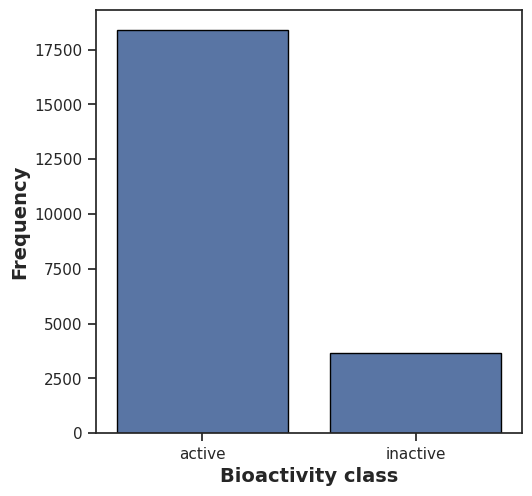

In [24]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

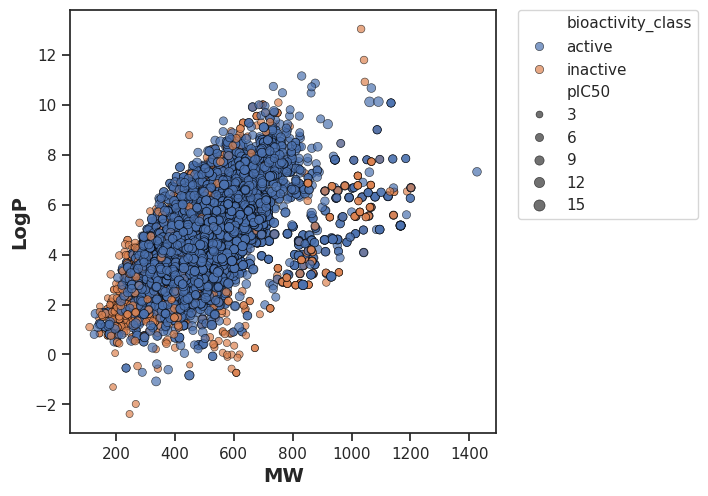

In [25]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

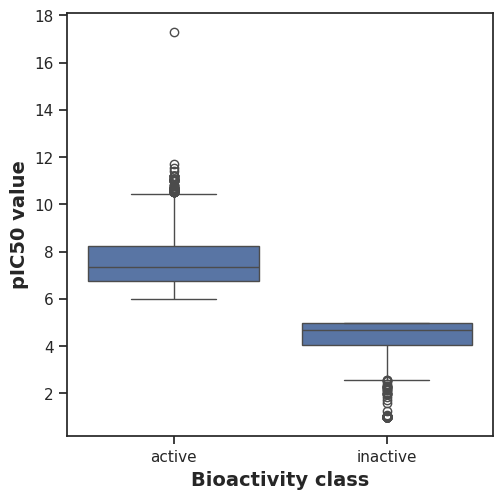

In [26]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [27]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [28]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,67042312.0,0.0,0.05,Different distribution (reject H0)


#### **MW**

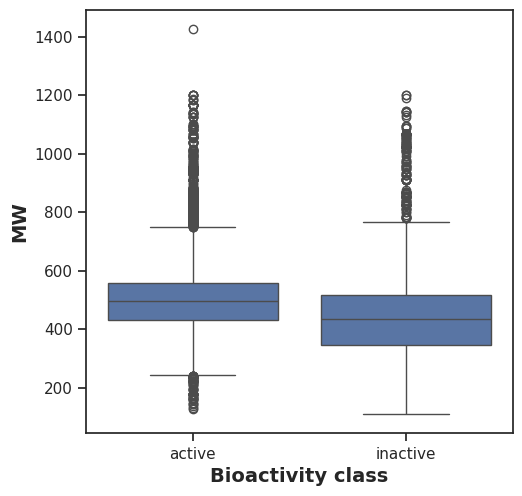

In [29]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [30]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,NaN,NaN,0.05,Different distribution (reject H0)


#### **LogP**

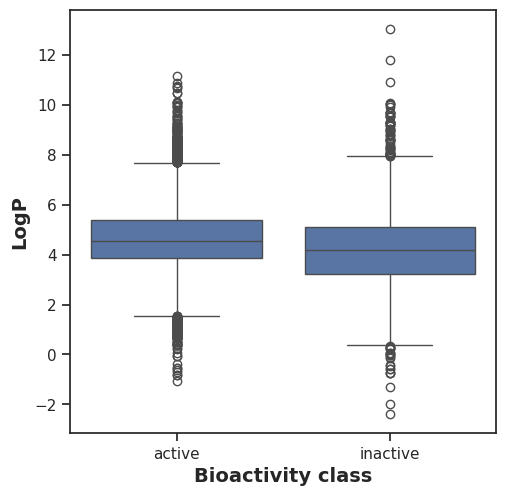

In [31]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [32]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,NaN,NaN,0.05,Different distribution (reject H0)


#### **NumHDonors**

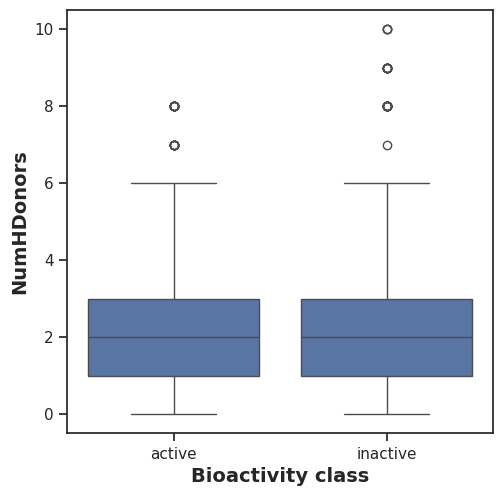

In [33]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [34]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,NaN,NaN,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

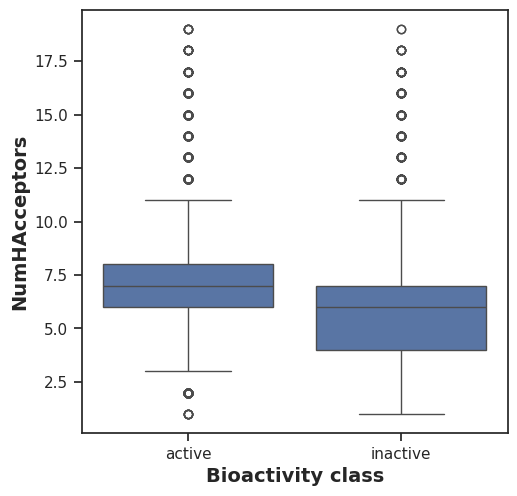

In [35]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [36]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,NaN,NaN,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

##### **Box Plots**

###### **pIC50 values**

Taking a look at pIC50 values, the **actives** and **inactives** displayed ***statistically significant difference***, which is to be expected since threshold values (``IC50 < 1,000 nM = Actives while IC50 > 10,000 nM = Inactives``, corresponding to ``pIC50 > 6 = Actives and pIC50 < 5 = Inactives``) were used to define actives and inactives.

###### **Lipinski's descriptors**

Of the 4 Lipinski's descriptors (MW, LogP, NumHDonors and NumHAcceptors), only LogP exhibited ***no difference*** between the **actives** and **inactives** while the other 3 descriptors (MW, NumHDonors and NumHAcceptors) shows ***statistically significant difference*** between **actives** and **inactives**.

## **Zip files**

In [37]:
! zip -r results.zip . -i *.csv *.pdf

  adding: plot_NumHDonors.pdf (deflated 38%)
  adding: mannwhitneyu_pIC50.csv (deflated 8%)
  adding: plot_MW_vs_LogP.pdf (deflated 1%)
  adding: mannwhitneyu_LogP.csv (deflated 6%)
  adding: plot_MW.pdf (deflated 32%)
  adding: bioactivity_data_2class.csv (deflated 84%)
  adding: plot_LogP.pdf (deflated 31%)
  adding: mannwhitneyu_MW.csv (deflated 6%)
  adding: plot_ic50.pdf (deflated 36%)
  adding: bioactivity_preprocessed_data.csv (deflated 87%)
  adding: plot_NumHAcceptors.pdf (deflated 38%)
  adding: plot_bioactivity_class.pdf (deflated 39%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 9%)
